In [1]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import matplotlib.colors as mcol
import matplotlib.cm as mcm
import scipy.stats as sts
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
import scipy.optimize as sopt
from sim_read import *

plt.style.use('./presentation.mplstyle')

In [2]:
gls = sim(exgrp_fields=['GroupFirstSub'],exsub_fields=['SubhaloMass'])
sim.mass_add(gls)

/Users/bhattacharyya.37/TNG50-1/sim_read.py:28: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst, 'group_m200', mconv + np.log10(self.hst.Group_M_Crit200))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:29: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst,'group_mst', mconv + np.log10(self.hst.GroupMassType[:,4]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:30: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mgas', mconv + np.log10(self.sub.SubhaloMassInRadType[:,0]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:31: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mst',mconv + np.log10(self.sub.SubhaloMassInRadType[:,4]))


In [3]:
llt,llh,llg,llm,dhost = sim.gal_select(gls,hfloor=9)

N_lll = len(llh)
print(N_lll)

sfms_intercept,sfms_slope = dwf_sfms(gls.sub.mst,gls.sub.ssfr)

1494 10829
Ndh 5944
5311
1494 10829
-8.346120696830761 -0.17679571397785238


In [8]:
back_host = np.genfromtxt('backsplash.txt',usecols=0,dtype='int')
back_gal = np.genfromtxt('backsplash.txt',usecols=2,dtype='int')
back_dz0 = np.genfromtxt('backsplash.txt',usecols=3,dtype='float')
back_peri = np.genfromtxt('backsplash.txt',usecols=4,dtype='float')
back_snap = np.genfromtxt('backsplash.txt',usecols=5,dtype='int')


Nbsg = len(back_gal)
print(Nbsg)

llg_a = np.array([m for i in range(N_lll) for m in llg[i]])
llh_a = np.array([gls.hst.group_m200[h] for i in range(N_lll) for h in llg[i]])
mst_a = np.array([m for i in range(3) for m in gls.sub.mst[llg[i]]])


bklg,llg_int,bkg_int = np.intersect1d(llg_a, back_gal, return_indices=True)
print(len(bklg))

snap_z = np.genfromtxt('snap_z_age.txt',usecols=1)
snap_tl = np.genfromtxt('snap_z_age.txt',usecols=3)

1257
361


222


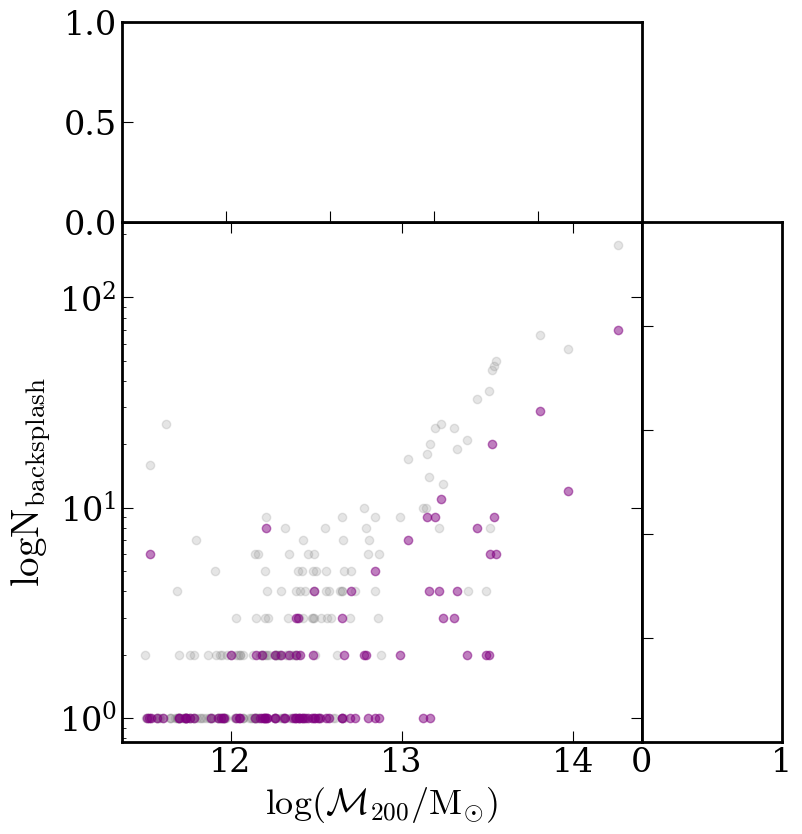

In [5]:
left, width = 0.175, 0.65
bottom, height = 0.1, 0.65
spacing = 0.0


rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.25]
rect_histy = [left + width + spacing, bottom, 0.175, height]

plt.figure(figsize=(8, 8))

ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction='in', top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.tick_params(direction='in', labelbottom=False)
ax_histy = plt.axes(rect_histy)
ax_histy.tick_params(direction='in', labelleft=False)

ax_scatter.set_xlabel(r'$log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)
ax_scatter.set_ylabel(r'$log N_{backsplash}$',fontsize=28)

back_llh,back_mem = np.unique(back_host,return_inverse=True)
Nunc = len(back_llh)
print(Nunc)

back_arr = np.zeros((Nunc,3))
for l in range(Nunc): 
    lg = back_gal[np.where(l==back_mem)[0]]
    lgm200 = gls.hst.group_m200[gls.sub.SubhaloGrNr[lg]]
    back_mst = lg[np.where((gls.sub.mst[lg]>=7.5)&(gls.sub.mst[lg]<9.5))[0]]
    back_mh = lg[np.where((gls.sub.mst[lg]>=7.5)&(gls.sub.mst[lg]<9.5)&(lgm200>=9.5)&(lgm200<11.5))[0]]

    
    back_arr[l,:]=gls.hst.group_m200[back_llh[l]],len(back_mst),len(back_mh)
    #bklg,llg_int,bkg_int = np.intersect1d(llg_a, lg, return_indices=True)
    #print(len(lg),len(bklg))
ax_scatter.scatter(back_arr[:,0],back_arr[:,1],color='gray',alpha=0.2)
ax_scatter.scatter(back_arr[:,0],back_arr[:,2],color='purple',alpha=0.5)
ax_scatter.set_yscale('log')
#ax_histy.hist(np.log10(back_arr[:,1]),bins=np.linspace(0,2,8),color='black',histtype='step',lw=3,density=True,orientation='horizontal')
#ax_histx.hist(back_arr[:,0],bins=np.linspace(11,14.5,6),weights=back_arr[:,1],color='black',lw=3,histtype='step',density=True)

plt.savefig('backsplash_distrib.pdf',bbox_inches='tight')

Text(0, 0.5, '$f_{backspl}$')

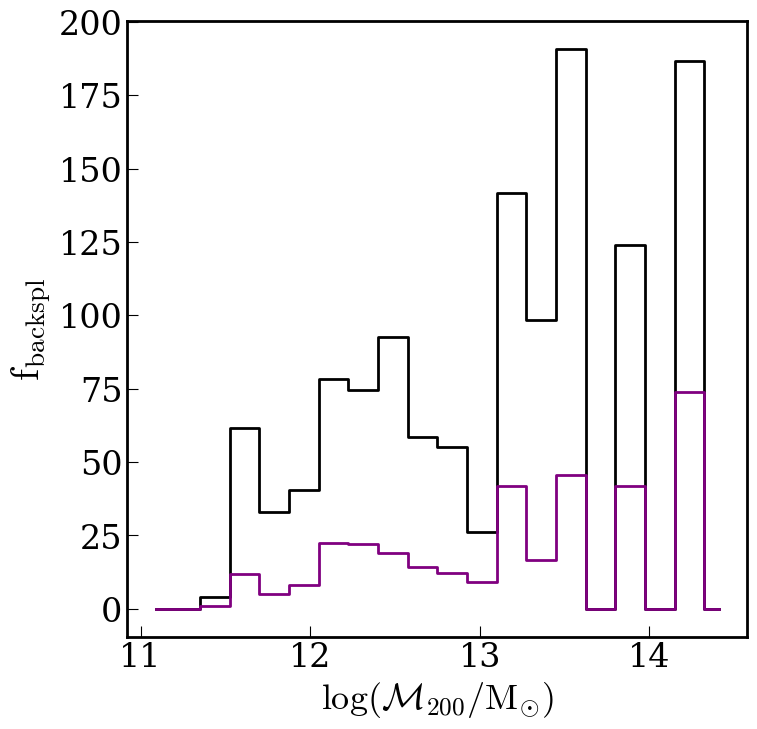

In [7]:
fig,ax=plt.subplots(figsize=(8,8),sharex=True)

Nbtsp =2000
boot_arr = np.zeros((Nbtsp,2,20))
mh_bins = np.linspace(11,14.5,21)

for i in range(Nbtsp):
    boot = npr.choice(range(Nunc),size=Nunc,replace=True)

    boot_arr[i,0,:], bin_edg, _ = sts.binned_statistic(back_arr[boot,0],back_arr[boot,1],statistic='sum', bins=mh_bins)
    boot_arr[i,1,:], bin_edg, _ = sts.binned_statistic(back_arr[boot,0],back_arr[boot,2],statistic='sum', bins=mh_bins)
    
#np.histogram(back_arr[:,0],weights=back_arr[:,1],bins=)
bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
ax.step(bin_edg[:-1],np.mean(boot_arr[:,0,:],axis=0),color='black',lw=2,where='mid')
ax.step(bin_edg[:-1],np.mean(boot_arr[:,1,:],axis=0),color='purple',lw=2,where='mid')

ax.set_xlabel(r'$log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)
ax.set_ylabel(r'$f_{backspl}$',fontsize=28)

#plt.savefig('backsplash_convol.pdf',bbox_inches='tight')


1.336 3.621 9.51


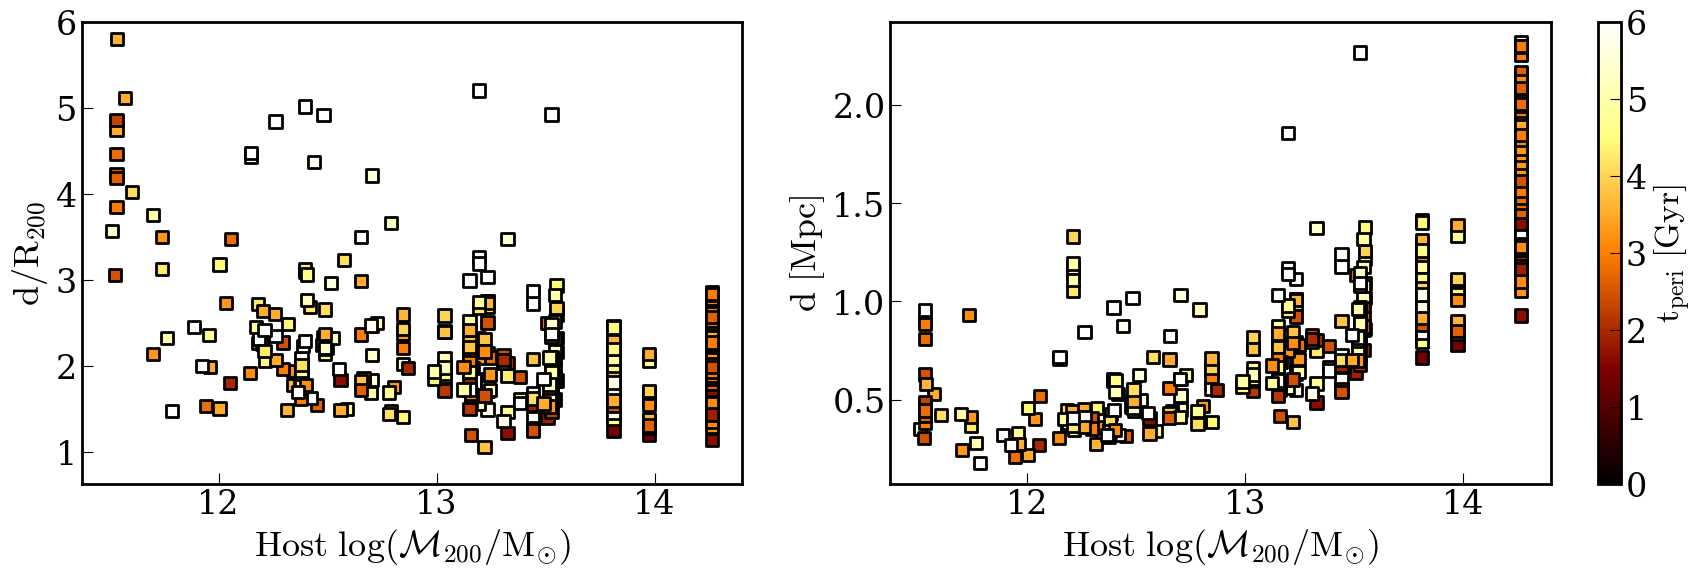

In [6]:
fig,ax=plt.subplots(1,4,figsize=(20,6),width_ratios=[0.49,0.01,0.49,0.01])

tperi = []
#back_arr = np.zeros((Nunc,2))
for l in range(Nunc): 
    lg = back_gal[np.where(l==back_mem)[0]]
    lp = back_dz0[np.where(l==back_mem)[0]]
    ltl = back_snap[np.where(l==back_mem)[0]]

    lgm200 = gls.hst.group_m200[gls.sub.SubhaloGrNr[lg]]
    lselc = np.where((gls.sub.mst[lg]>=7.5)&(gls.sub.mst[lg]<9.5)&(lgm200>=9)&(lgm200<11.5))[0]
   
    #back_arr[l,:]=gls.hst.group_m200[back_llh[l]],len(back_mst)
    tperi.extend(snap_tl[ltl[lselc]])
   
    ax[0].scatter(gls.hst.group_m200[back_llh[l]]*np.ones(len(lselc)),lp[lselc]/gls.hst.Group_R_Crit200[back_llh[l]],s=80,c=snap_tl[ltl[lselc]],cmap=mcm.afmhot,vmin=0,vmax=6,edgecolors='black',marker='s',linewidth=2)
    ax[2].scatter(gls.hst.group_m200[back_llh[l]]*np.ones(len(lselc)),1e-3*lp[lselc],s=80,c=snap_tl[ltl[lselc]],cmap=mcm.afmhot,vmin=0,vmax=6,edgecolors='black',marker='s',linewidth=2)

print(min(tperi),np.median(tperi),max(tperi))

ax[1].set_axis_off()
ax[3].set_axis_off()
ax[0].set_ylim(top=6)
ax[0].set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)
ax[2].set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)

ax[0].set_ylabel(r'$d/R_{200}$',fontsize=26)
ax[2].set_ylabel(r'$d\ [Mpc]$',fontsize=26)

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=0, vmax=6),cmap=mcm.afmhot), ax=ax[3], orientation='vertical',fraction=2.5,label=r'$t_{\rm peri}\ [Gyr]$')

plt.savefig('backsplash_convol.pdf',bbox_inches='tight')


Text(0, 0.5, '$d\\ [Mpc]$')

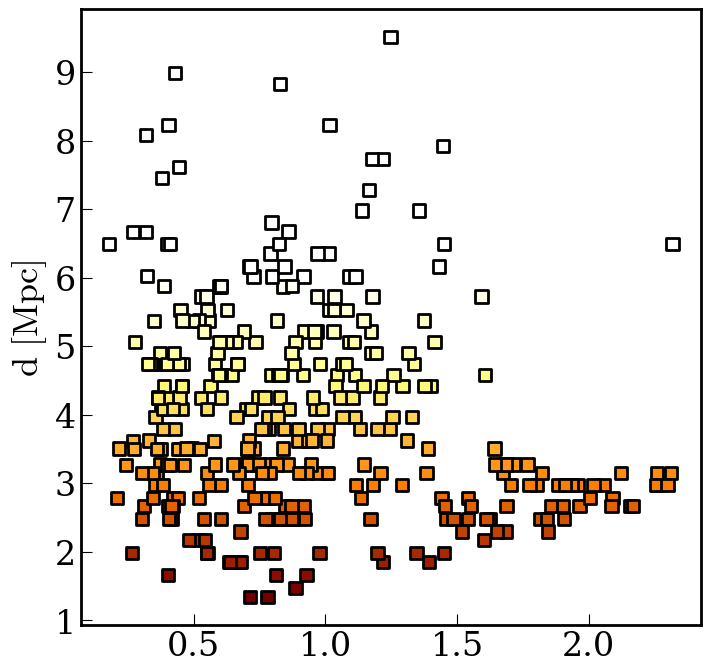

In [11]:
fig,ax=plt.subplots(figsize=(8,8),sharex=True)


for l in range(Nunc): 
    lg = back_gal[np.where(l==back_mem)[0]]
    lp = back_dz0[np.where(l==back_mem)[0]]
    ltl = back_snap[np.where(l==back_mem)[0]]

    lgm200 = gls.hst.group_m200[gls.sub.SubhaloGrNr[lg]]
    lselc = np.where((gls.sub.mst[lg]>=7.5)&(gls.sub.mst[lg]<9.5)&(lgm200>=9.5)&(lgm200<11.5))[0]
   
    #back_arr[l,:]=gls.hst.group_m200[back_llh[l]],len(back_mst)
    tperi.extend(snap_tl[ltl[lselc]])
   
    ax.scatter(1e-3*lp[lselc],snap_tl[ltl[lselc]],s=80,c=snap_tl[ltl[lselc]],cmap=mcm.afmhot,vmin=0,vmax=6,edgecolors='black',marker='s',linewidth=2)

ax.set_ylabel(r'$d\ [Mpc]$',fontsize=26)


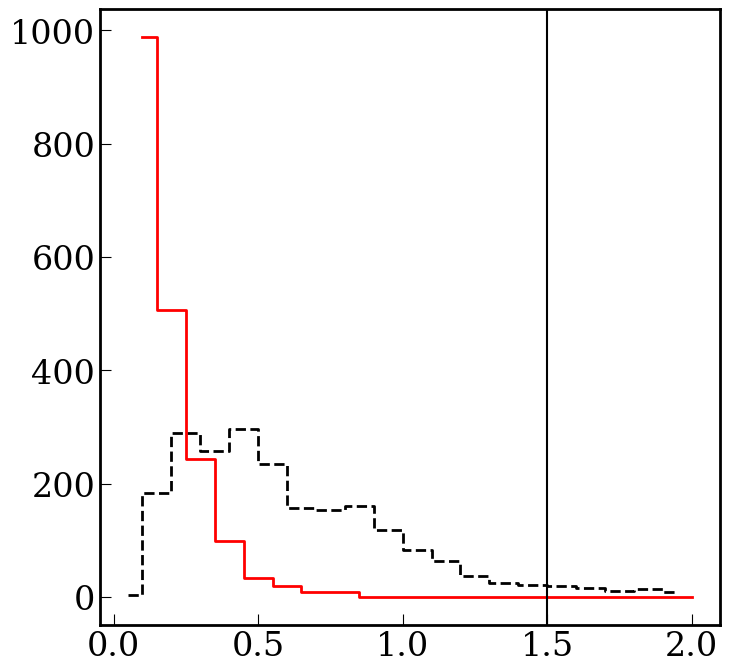

In [18]:
fig,ax=plt.subplots(figsize=(8,8),sharex=True)

dhst_bins = np.linspace(0,2,21)
#bin_ls = ['-',':','--']

#qnc_a = gls.sub.ssfr[llg[k]]-(sfms_intercept -1 + sfms_slope*np.array(gls.sub.mst[llg[k]]))
#red = np.where(qnc_a<0)[0]
#blue = np.where(qnc_a>=0)[0]

bin_sat, bin_edg = np.histogram(back_peri*1e-3,bins=dhst_bins)
bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
ax.step(bin_edg[:-1],bin_sat,color='black',ls='--',lw=2,where='mid')

bin_sat, bin_edg = np.histogram(back_dz0*1e-3,bins=dhst_bins)
bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
ax.step(bin_edg[:-1],bin_sat,color='red',lw=2,where='mid')

ax.axvline(1.5,color='black')

In [8]:
sfms_intercept,sfms_slope = dwf_sfms(gls.sub.mst,gls.sub.ssfr)

llt,llh,llg,llm,dhost = back_selc()

Nll = len(llh)
print(Nll)

host_bins = [np.where(llm==1)[0],np.where((llm>1))[0]]
bin_cols = ['crimson','royalblue']
bin_mk = ['o','D','s']
print(len(host_bins[0]),len(host_bins[1]))



1464 16399
-9.129322318740096 -0.08497814342808867
1464 16399
987
230
210 20


In [9]:
mst_a = np.array([m for i in range(Nll) for m in gls.sub.mst[llg[i]]])
llt_a = np.array([t for i in range(Nll) for t in llt[i]])
llh_a = np.array([llh[i] for i in range(Nll) for m in range(llm[i])])
dhost_a = np.array([d for i in range(Nll) for d in dhost[i]])

ssfr_a = np.array([s for i in range(Nll) for s in gls.sub.ssfr[llg[i]]])
dsfms_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))
#g_i = [gi for i in range(Nll) for gi in (gls.sub.SubhaloStellarPhotometrics[llg[i],4] - gls.sub.SubhaloStellarPhotometrics[llg[i],5])]


In [12]:
def behroozi(M,M1=11.59,A=-1.459,alpha=-1.972,beta=-0.488,gamma=-0.958,delta=0.391): 
    x = M - M1
    return  M1 + A - np.log10(np.power(10,alpha*x) + np.power(10,beta*x))+np.exp(-0.5*np.square(x/delta)) * 10**gamma

def most(M,M1=11.59,A=2*0.0351,beta=1.376,gamma=0.608): 
    return np.log10(A) + M - np.log10(np.power(10,-beta*(M-M1))+np.power(10,gamma*(M-M1)))

mhalo_bin = np.linspace(10,11.5,50)

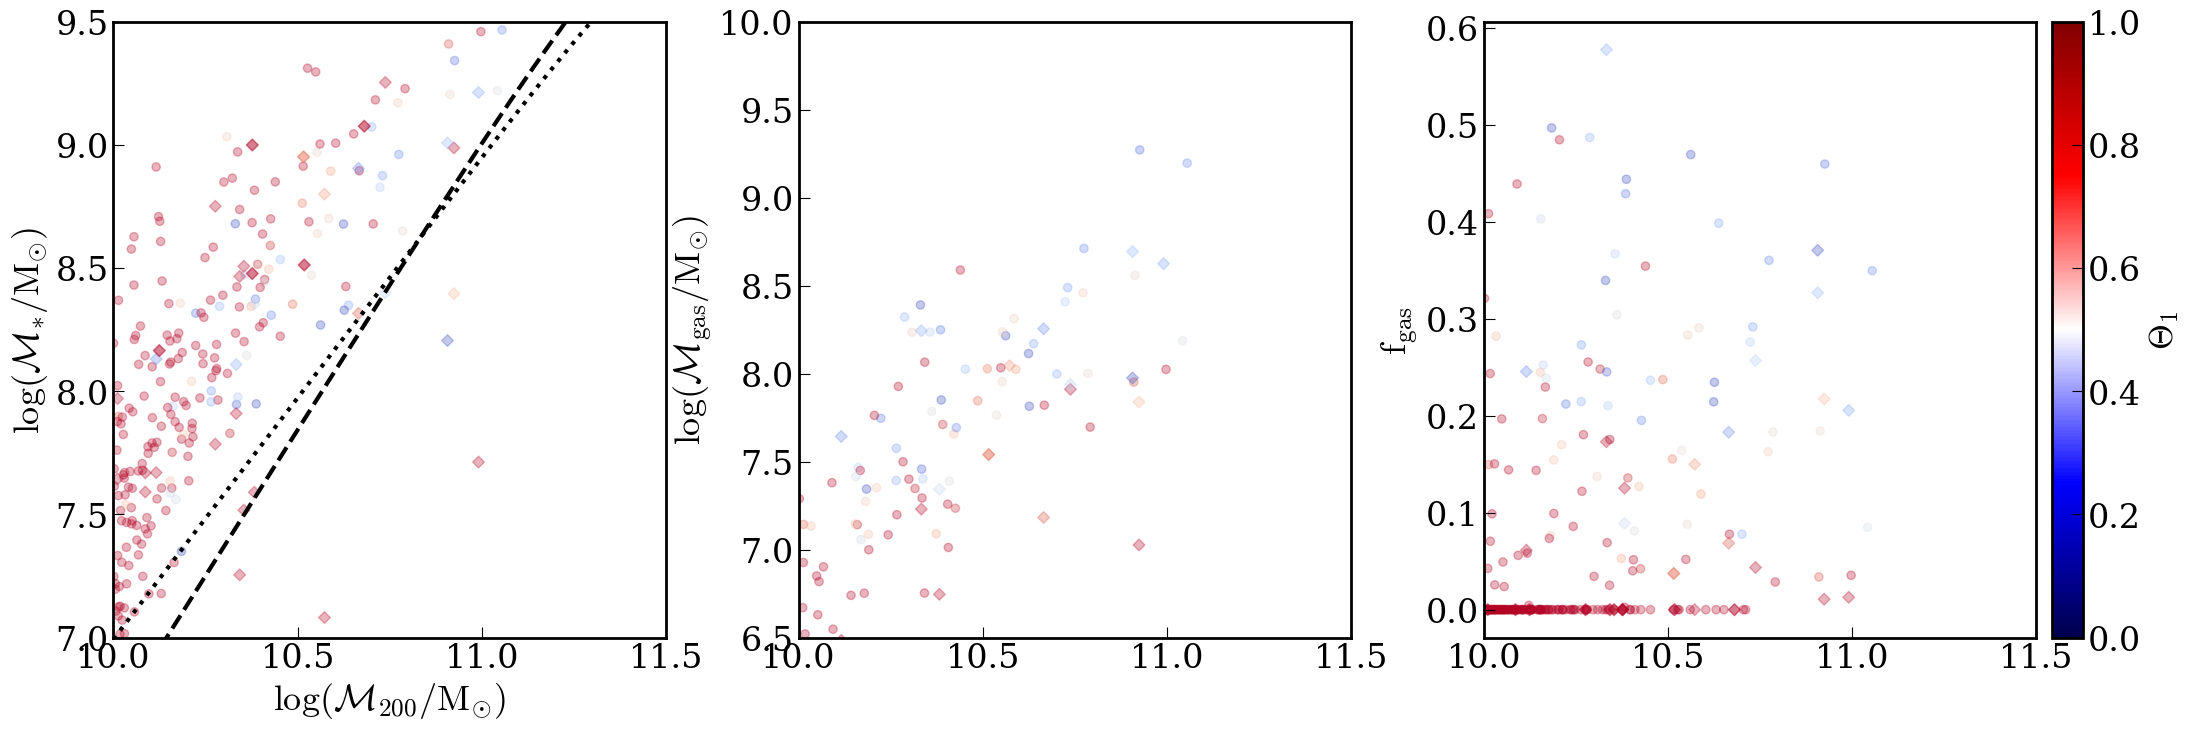

In [13]:
fig,ax=plt.subplots(1,6,figsize=(26,8),sharex=True,width_ratios=[0.32,0.01,0.32,0.01,0.32,0.02])

#dhst_bins = np.linspace(np.log10(0.15),np.log10(15),6)

for k in range(2):
    dhost_a = np.log10([d for i in host_bins[k] for d in dhost[i]])
    mst_a = np.array([m for i in host_bins[k] for m in gls.sub.mst[llg[i]]])
    mgas_a = np.array([m for i in host_bins[k] for m in gls.sub.mgas[llg[i]]])
    #llt_a = np.array([t for i in host_bins[k] for t in llt[i]])
    llh_a = np.array([llh[i] for i in host_bins[k] for m in range(llm[i])])
    gas_frac = np.power(10,mgas_a)/(np.power(10,mgas_a)+np.power(10,mst_a))

    ssfr_a = np.array([s for i in host_bins[k] for s in gls.sub.ssfr[llg[i]]])
    dsfms_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))
    
    ax[0].scatter(llh_a,mst_a,c=dsfms_a,cmap=mcm.afmhot,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k]) 
    ax[2].scatter(llh_a,mgas_a,c=dsfms_a,cmap=mcm.afmhot,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k]) 
    ax[4].scatter(llh_a,gas_frac,c=dsfms_a,cmap=mcm.afmhot,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k]) 

    ax[k].set_xlabel(r'$log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)


ax[0].set_xlim((10,11.5))
ax[0].set_ylim((7,9.5))
ax[2].set_ylim((6.5,10))
ax[5].set_ylim((1e-2,1))
      
ax[0].plot(mhalo_bin,most(mhalo_bin),lw=3,ls='--',color='black')
ax[0].plot(mhalo_bin,behroozi(mhalo_bin),lw=3,ls=':',color='black')
ax[5].set_yscale('log')
ax[1].set_axis_off()
ax[3].set_axis_off()
ax[5].set_axis_off()

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=0,vmax=1),cmap=mcm.seismic), ax=ax[5], orientation='vertical',fraction=2.2,label=r'$\Theta_1$',pad=-1.)

ax[4].set_ylabel(r'$f_{gas}$',fontsize=26)
ax[2].set_ylabel(r'$log(\mathcal{M}_{gas}/M_{\odot})$',fontsize=26)
ax[0].set_ylabel(r'$log(\mathcal{M}_{\ast}/M_{\odot})$',fontsize=26)


ax[0].set_rasterized(True)
ax[2].set_rasterized(True)
plt.subplots_adjust(wspace=0.2)


In [29]:
#host_bins = [np.where((llh<11.5)&(llm==1))[0],np.where((llh<11.5)&(llm>1))[0],np.where(llh>=11.5)[0]]
#print(len(host_bins[0]),len(host_bins[1]),len(host_bins[2]))

bin_cols = ['royalblue','royalblue','black']
bin_ls = ['-',':','-']
bin_mk = ['o','D','s']
bin_lbl = [r'$dwarf\ centrals$',r'$dwarf\ groups$',r'$dwarf\ satellites$']

In [14]:
dconv = 1.428571429e-3
x_a = np.array([x for i in range(Nll) for x in gls.sub.SubhaloPos[llg[i],0]])*dconv - 25
y_a = np.array([y for i in range(Nll) for y in gls.sub.SubhaloPos[llg[i],1]])*dconv - 25
z_a = np.array([z for i in range(Nll) for z in gls.sub.SubhaloPos[llg[i],2]])*dconv - 25

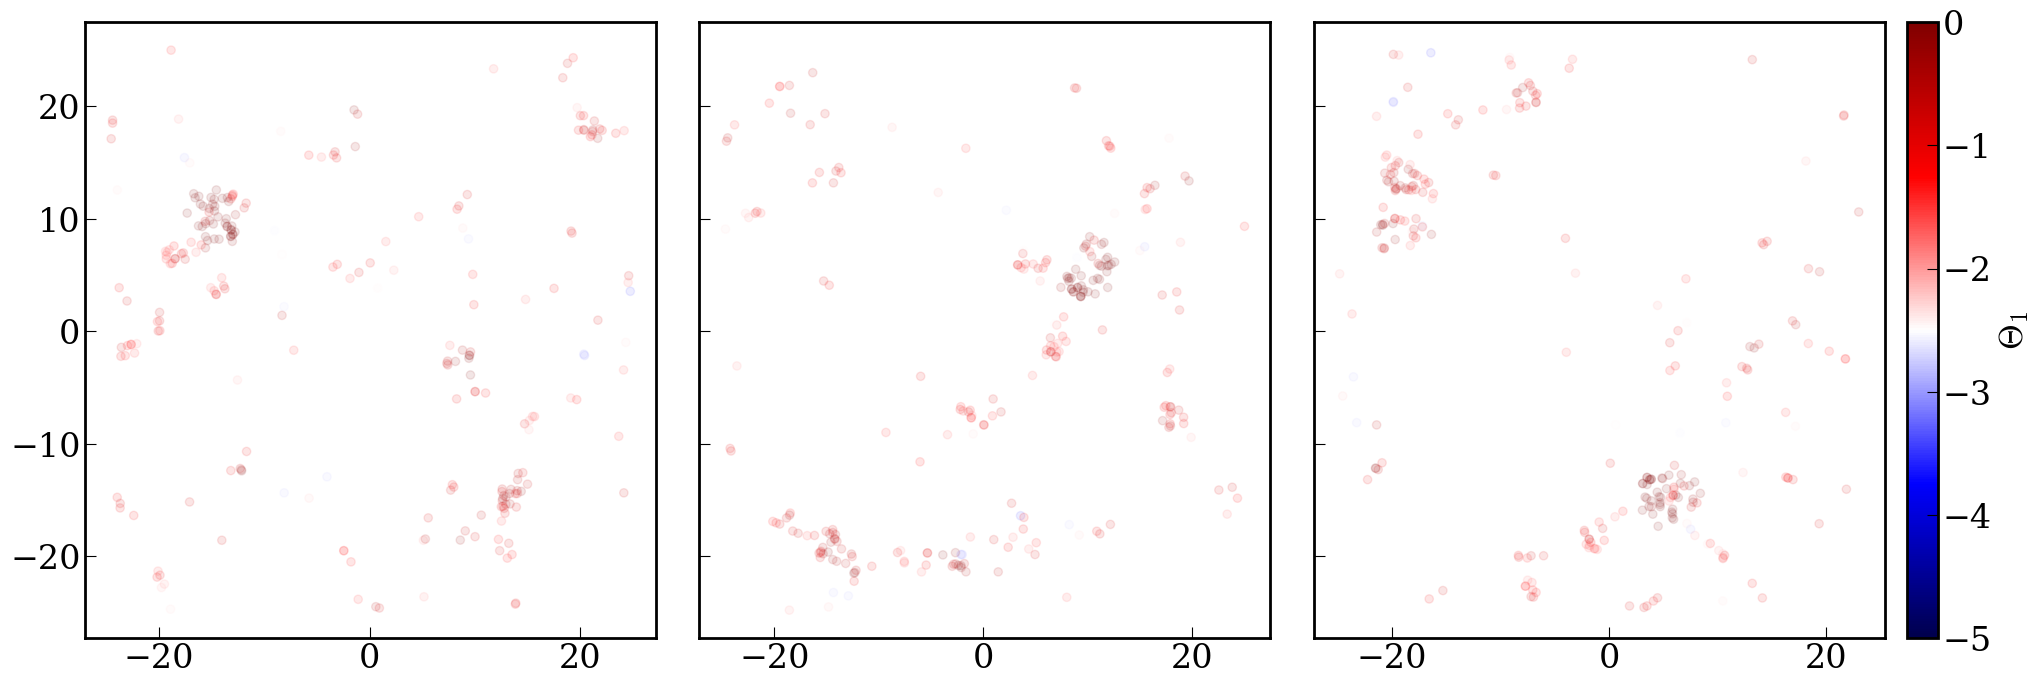

In [16]:
fig,ax=plt.subplots(1,4,figsize=(24,8),sharey=True,width_ratios=[0.33,0.33,0.33,0.01])

ax[0].scatter(x_a,y_a,marker='o',c=llt_a,cmap=mcm.seismic,vmin=-5,vmax=0,alpha=0.1)
ax[1].scatter(y_a,z_a,marker='o',c=llt_a,cmap=mcm.seismic,vmin=-5,vmax=0,alpha=0.1)
ax[2].scatter(z_a,x_a,marker='o',c=llt_a,cmap=mcm.seismic,vmin=-5,vmax=0,alpha=0.1)

for j in range(3):
    ax[0].set_rasterized(True)

ax[3].set_axis_off()
'''
ax[0].set_xlabel(r'$x[Mpc]$'fontsize=30)
ax[0].set_ylabel(r'$y[Mpc]$'fontsize=30)
ax[1].set_xlabel(r'$y[Mpc]$'fontsize=30)
ax[1].set_ylabel(r'$z[Mpc]$'fontsize=30)
ax[2].set_xlabel(r'$z[Mpc]$'fontsize=30)
ax[2].set_ylabel(r'$x[Mpc]$'fontsize=30)
'''
fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-5, vmax=0),cmap=mcm.seismic), ax=ax[3], orientation='vertical',fraction=2.2,label=r'$\Theta_1$',pad=0.0)

plt.subplots_adjust(wspace=0.1)
plt.savefig('tidal_map.pdf',bbox_inches='tight')